# Декодирование сигналов Morse: Соревнование cryoarchive-incident
Этот ноутбук содержит решение для соревнования по декодированию искаженных сигналов азбуки Морзе.

In [12]:
import os
import zipfile
import random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import matplotlib
import kagglehub
import kagglehub.cache
import kagglehub.handle

SEED = 42
EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
TEST_SIZE = 0.2
DATASET_NAME = "cryoarchive-incident"
INTERACTIVE = True

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not INTERACTIVE:
    matplotlib.use("Agg")

## 1. Загрузка и подготовка датасета

In [13]:
handle = kagglehub.handle.parse_competition_handle(DATASET_NAME)
cache_path = Path(kagglehub.cache.get_cached_path(handle))
marker_path = Path(kagglehub.cache._get_competitions_completion_marker_filepath(handle))

if cache_path.exists() and marker_path.exists():
    path = cache_path
else:
    from kagglehub.auth import get_username
    username = get_username()
    if username is None:
        print("Вы не авторизованы в Kaggle. Запуск процесса авторизации...")
        kagglehub.login()
        username = get_username()
        if username is None:
            raise RuntimeError("Пожалуйста, введите ваш API-токен Kaggle в интерактивном окне выше и запустите эту ячейку снова.")
    print(f"Вы авторизованы как пользователь: {username}")
    path = kagglehub.competition_download(DATASET_NAME)

DATA_DIR = Path(path)
zip_file = DATA_DIR / "morse_dataset_public.zip"
extracted_dir = DATA_DIR / "morse_dataset_public"

if not extracted_dir.exists():
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

TRAIN_DIR = DATA_DIR / "morse_dataset_public" / "morse_dataset" / "train"
TEST_DIR = DATA_DIR / "morse_dataset_public" / "morse_dataset" / "test"
LABELS_CSV = TRAIN_DIR / "labels.csv"
SAMPLE_SUBMISSION_CSV = DATA_DIR / "sample_submission.csv"

## 2. Разведочный анализ данных (EDA)

(30000, 2)
    filename     text
0  00000.wav  7 8 1 0
1  00001.wav   379466
2  00002.wav  8 7 0 2
3  00003.wav    88 19
4  00004.wav   34 176


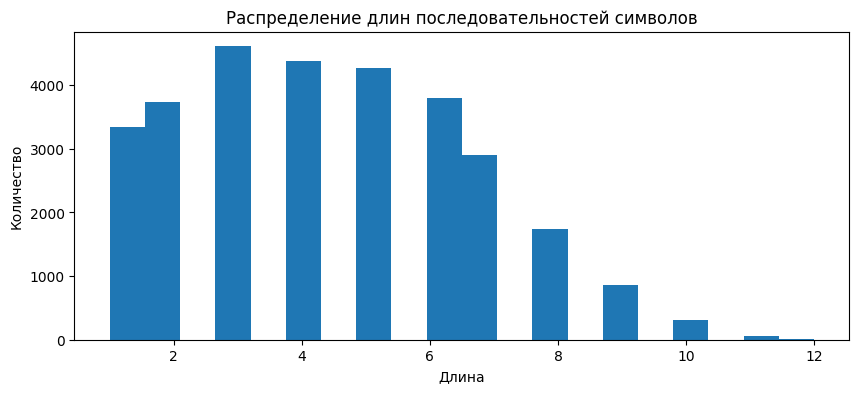

Частота дискретизации: 8000 Гц, Длина: 40000 отсчетов


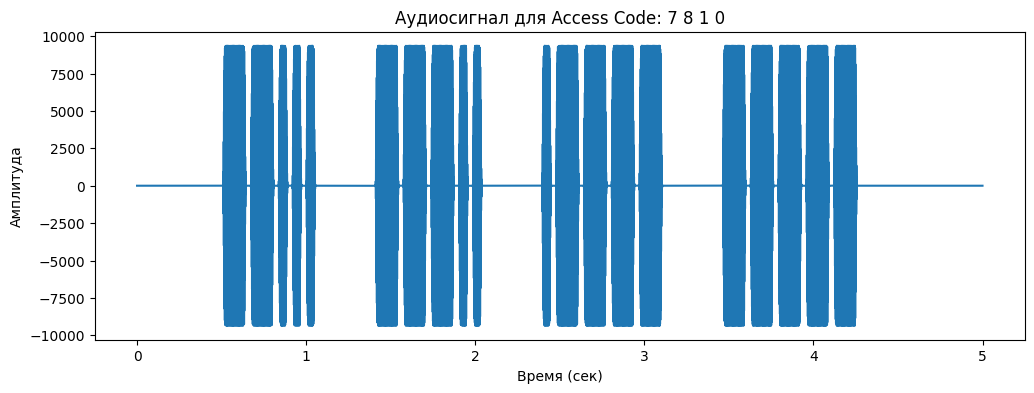

In [14]:
df = pd.read_csv(LABELS_CSV)
print(df.shape)
print(df.head())

lengths = df["text"].astype(str).str.len()
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=20)
plt.title("Распределение длин последовательностей символов")
plt.xlabel("Длина")
plt.ylabel("Количество")
plt.show()

sample_filename = df.iloc[0]["filename"]
sample_wav = TRAIN_DIR / sample_filename
sr, y = wavfile.read(sample_wav)
print(f"Частота дискретизации: {sr} Гц, Длина: {len(y)} отсчетов")

plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, len(y) / sr, len(y)), y)
plt.title(f"Аудиосигнал для Access Code: {df.iloc[0]['text']}")
plt.xlabel("Время (сек)")
plt.ylabel("Амплитуда")
plt.show()

## 3. Словарь символов и разделение выборки

In [15]:
df = pd.read_csv(LABELS_CSV)
train_df, val_df = train_test_split(df, test_size=TEST_SIZE, random_state=SEED)

all_chars = set()
for text in df["text"].astype(str):
    all_chars.update(text)
unique_chars = sorted(list(all_chars))

char_to_idx = {char: idx for idx, char in enumerate(unique_chars, start=1)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx) + 1

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер валидационной выборки: {len(val_df)}")
print(f"Уникальные символы в словаре ({len(unique_chars)}): {unique_chars}")

Размер обучающей выборки: 24000
Размер валидационной выборки: 6000
Уникальные символы в словаре (11): [' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## 4. Класс датасета и загрузчик данных

In [16]:
class MorseDataset(Dataset):
    def __init__(self, dataframe, audio_dir, is_test=False):
        self.df = dataframe
        self.audio_dir = Path(audio_dir)
        self.filenames = dataframe["filename"].values
        self.texts = dataframe["text"].values if ("text" in dataframe.columns and not is_test) else None

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        wav_path = self.audio_dir / self.filenames[idx]
        sr, y = wavfile.read(wav_path)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        if self.texts is not None:
            text = self.texts[idx]
            label_indices = torch.tensor([char_to_idx[c] for c in str(text)], dtype=torch.long)
            return y_tensor, label_indices
        return y_tensor, self.filenames[idx]

def extract_features(y):
    window = torch.hann_window(256)
    stft = torch.stft(y, n_fft=256, hop_length=128, win_length=256, window=window, return_complex=True)
    spectrogram = torch.log(torch.abs(stft) + 1e-6)
    return spectrogram

def collate_fn(batch):
    audios = [item[0] for item in batch]
    features = [extract_features(a).T for a in audios]
    input_lengths = torch.tensor([f.size(0) for f in features], dtype=torch.long)
    features_padded = nn.utils.rnn.pad_sequence(features, batch_first=True)

    if len(batch[0]) > 1 and isinstance(batch[0][1], torch.Tensor):
        labels = [item[1] for item in batch]
        target_lengths = torch.tensor([len(label) for label in labels], dtype=torch.long)
        labels_padded = nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value=0)
        return features_padded, labels_padded, input_lengths, target_lengths
    else:
        filenames = [item[1] for item in batch]
        return features_padded, filenames, input_lengths

train_dataset = MorseDataset(train_df, TRAIN_DIR)
val_dataset = MorseDataset(val_df, TRAIN_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

## 5. Архитектура модели

In [17]:
class CRNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=2, bidirectional=True, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.cnn(x)
        x = x.transpose(1, 2)
        x, _ = self.rnn(x)
        x = self.fc(x)
        return x

def greedy_decode(output_probs):
    arg_maxes = torch.argmax(output_probs, dim=-1)
    decoded_sequences = []
    for seq in arg_maxes:
        decoded = []
        prev = -1
        for idx in seq:
            idx_val = idx.item()
            if idx_val != prev:
                if idx_val != 0:
                    decoded.append(idx_to_char[idx_val])
                prev = idx_val
        decoded_sequences.append("".join(decoded))
    return decoded_sequences

def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

## 6. Обучение и валидация

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CRNNModel(input_dim=129, hidden_dim=128, output_dim=num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)

best_lev = float("inf")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    total_samples = 0

    for features, labels, input_lengths, target_lengths in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        outputs_log_probs = torch.log_softmax(outputs, dim=-1)
        outputs_log_probs = outputs_log_probs.transpose(0, 1)

        loss = criterion(outputs_log_probs, labels, input_lengths, target_lengths)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * features.size(0)
        total_samples += features.size(0)

    epoch_loss = running_loss / total_samples

    model.eval()
    total_lev = 0.0
    val_samples = 0

    with torch.no_grad():
        for features, labels, input_lengths, target_lengths in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            features = features.to(device)
            outputs = model(features)
            outputs_probs = torch.softmax(outputs, dim=-1)

            decoded_preds = greedy_decode(outputs_probs)

            for idx, pred in enumerate(decoded_preds):
                label_seq = labels[idx][:target_lengths[idx]].tolist()
                true_str = "".join([idx_to_char[i] for i in label_seq])
                total_lev += levenshtein_distance(pred, true_str)
                val_samples += 1

    epoch_lev = total_lev / val_samples
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f} - Val Levenshtein: {epoch_lev:.4f}")

    if epoch_lev < best_lev:
        best_lev = epoch_lev
        torch.save(model.state_dict(), "best_crnn_model.pth")
        print("Сохранена лучшая модель")

Epoch 1/5 [Train]:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/5 - Loss: 4.6372 - Val Levenshtein: 4.3763
Сохранена лучшая модель


Epoch 2/5 [Train]:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 4/5 - Loss: 0.3437 - Val Levenshtein: 0.1465
Сохранена лучшая модель


Epoch 5/5 [Train]:   0%|          | 0/750 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 5/5 - Loss: 0.1112 - Val Levenshtein: 0.0558
Сохранена лучшая модель


## 7. Качественная оценка модели

In [18]:
model.load_state_dict(torch.load("best_crnn_model.pth", map_location=device))
model.eval()

with torch.no_grad():
    for features, labels, input_lengths, target_lengths in val_loader:
        features = features.to(device)
        outputs = model(features)
        outputs_probs = torch.softmax(outputs, dim=-1)
        decoded_preds = greedy_decode(outputs_probs)

        for idx in range(min(5, len(decoded_preds))):
            label_seq = labels[idx][:target_lengths[idx]].tolist()
            true_str = "".join([idx_to_char[i] for i in label_seq])
            print(f"True: {true_str} | Pred: {decoded_preds[idx]}")
        break

True: 74 1 | Pred: 74 1
True: 5 3 1 | Pred: 5 3 1
True: 771 | Pred: 771
True: 1 3 9 6 | Pred: 1 3 9 6
True: 0433 | Pred: 0433


## 8. Инференс на тестовой выборке и генерация сабмишна

In [19]:
test_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
test_dataset = MorseDataset(test_df, TEST_DIR, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

model = CRNNModel(input_dim=129, hidden_dim=128, output_dim=num_classes).to(device)
model.load_state_dict(torch.load("best_crnn_model.pth", map_location=device))
model.eval()

predictions = []
filenames_list = []

with torch.no_grad():
    for features, filenames, input_lengths in tqdm(test_loader, desc="Inference"):
        features = features.to(device)
        outputs = model(features)
        outputs_probs = torch.softmax(outputs, dim=-1)
        decoded_preds = greedy_decode(outputs_probs)
        predictions.extend(decoded_preds)
        filenames_list.extend(filenames)

submission = pd.DataFrame({
    "filename": filenames_list,
    "text": predictions
})
submission.to_csv("submission.csv", index=False)
print("Файл submission.csv успешно сохранен.")

Inference:   0%|          | 0/157 [00:00<?, ?it/s]

Файл submission.csv успешно сохранен.


## 9. Проверка сабмишна

In [21]:
sub = pd.read_csv("submission.csv", keep_default_na=False)
print(f"Формат сабмишна: {sub.shape}")
print(sub.head())
print(f"Есть ли пропущенные значения: {sub.isnull().any().any()}")

Формат сабмишна: (5000, 2)
    filename text
0  00000.wav    0
1  00001.wav     
2  00002.wav    0
3  00003.wav     
4  00004.wav    0
Есть ли пропущенные значения: False
